In [10]:
from collections import defaultdict
from tqdm import tqdm
from human_eval.execution import check_correctness
from human_eval.data import read_problems
import re
from openai import OpenAI
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

LLM_MODELS = ["google/palm-2-codechat-bison", "meta-llama/llama-3-8b-instruct", "google/gemma-3-12b-it", "deepseek/deepseek-r1-distill-llama-8b"]
NUM_TASKS = 100
NUM_ATTEMPTS = 2

problems = dict(list(read_problems().items())[:NUM_TASKS])

In [5]:
def clean_completion(text):
    match = re.search(r"```(?:python)?\n(.*?)```", text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()

def generate_completion(prompt, llm, temperature=0.05, max_completion_tokens=200):
    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key="<API-Token>",
    )
    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model=llm,
        temperature=temperature,
        max_completion_tokens=max_completion_tokens,
    )
    if chat_completion :
        return chat_completion.choices[0].message.content
    else:
        return ""

def build_feedback_prompt(base_prompt, history):
    feedback = "\n\nPrevious attempts:\n"
    for i, prev in enumerate(history, 1):
        feedback += f"Attempt {i}:\n{prev}\n\n"
    feedback += "These attempts failed. Please improve the solution. Return only the code."
    return f"{base_prompt}\n\n{feedback}"

def run_banchmark():
    all_samples = defaultdict(list)

    for model in LLM_MODELS:
        print(f"Generating for {model}")
        for task_id, task in tqdm(problems.items()):
            history = []
            for i in range(NUM_ATTEMPTS):
                if i == 0:
                    prompt = f"Return only the code, without any additional comments or explanations.\n{task['prompt']}"
                else:
                    prompt = build_feedback_prompt(task["prompt"], history)

                completion = generate_completion(prompt, model)
                cleaned = clean_completion(completion)

                result = check_correctness(task, cleaned, timeout=5)

                if result["passed"]:
                    all_samples[model].append({  
                        "task_id": task_id,
                        "completion": completion,
                        "attempt": i + 1,
                        "passed": result["passed"],
                        "result": result["result"]
                    })
                    break 

                history.append(completion) 
            save_samples_to_json({model: all_samples[model]}, filename="benchmark_results.json")
    return all_samples

import threading

def run_model_benchmark(model, all_samples, lock):
    print(f"Generating for {model}")
    local_results = []

    for task_id, task in tqdm(problems.items(), desc=f"{model}", leave=False):
        history = []
        for i in range(NUM_ATTEMPTS):
            if i == 0:
                prompt = f"Return only the code, without any additional comments or explanations.\n{task['prompt']}"
            else:
                prompt = build_feedback_prompt(task["prompt"], history)

            completion = generate_completion(prompt, model)
            cleaned = clean_completion(completion)
            result = check_correctness(task, cleaned, timeout=5)

            if result["passed"]:
                local_results.append({
                    "task_id": task_id,
                    "completion": completion,
                    "attempt": i + 1,
                    "passed": result["passed"],
                    "result": result["result"]
                })
                break

            history.append(completion)

    with lock:
        all_samples[model] = local_results
        save_samples_to_json({model: local_results}, filename="benchmark_results.json")

def run_banchmark_threaded():
    all_samples = defaultdict(list)
    lock = threading.Lock()
    threads = []

    for model in LLM_MODELS:
        t = threading.Thread(target=run_model_benchmark, args=(model, all_samples, lock))
        t.start()
        threads.append(t)

    for t in threads:
        t.join()

    return all_samples


def save_samples_to_json(new_samples, filename="benchmark_results.json"):
    if os.path.exists(filename):
        with open(filename, "r", encoding="utf-8") as f:
            existing_samples = json.load(f)
    else:
        existing_samples = {}

    for model, entries in new_samples.items():
        if model in existing_samples:
            existing_samples[model].extend(entries)
        else:
            existing_samples[model] = entries

    with open(filename, "w", encoding="utf-8") as f:
        json.dump(existing_samples, f, indent=2, ensure_ascii=False)
    print(f"Appended results to {filename}")


def compute_success_rate(successful_tasks, total_tasks):
    if total_tasks == 0:
        return 0
    return successful_tasks / total_tasks

def compute_avg_tca(total_attempts_for_success, successful_tasks):
    if successful_tasks == 0:
        return float('inf')
    return total_attempts_for_success / successful_tasks

def compute_success_efficiency(sr, avg_tca, max_attempts):
    if sr == 0 or avg_tca == float('inf') or max_attempts == 1:
        return 0
    exponent = (avg_tca - 1) / (max_attempts - 1)
    return sr / (avg_tca ** exponent)

def calculate_metrics(all_samples, num_tasks, max_attempts):
    metrics_dict = {}

    for model, completions in all_samples.items():
        task_attempts = defaultdict(list)
        for entry in completions:
            task_attempts[entry["task_id"]].append(entry)

        successful_tasks = len(task_attempts)

        total_attempts_for_success = 0
        for task_id, attempts in task_attempts.items():
            first_attempt = min(attempts, key=lambda x: x["attempt"])
            total_attempts_for_success += first_attempt["attempt"]

        sr = compute_success_rate(successful_tasks, num_tasks)
        avg_tca = compute_avg_tca(total_attempts_for_success, successful_tasks)
        se = compute_success_efficiency(sr, avg_tca, max_attempts)

        metrics_dict[model] = {
            "SR": sr,
            "AvgTCA": avg_tca,
            "SE": se,
            "Successful Tasks": successful_tasks,
            "Total Tasks": num_tasks
        }

    return metrics_dict

def plot_se_relationships(metrics_dict):
    models = list(metrics_dict.keys())
    sr = [metrics_dict[m]["SR"] for m in models]
    avg_tca = [metrics_dict[m]["AvgTCA"] for m in models]
    se = [metrics_dict[m]["SE"] for m in models]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Plot SE vs SR
    axs[0].scatter(sr, se, color='blue')
    for i, model in enumerate(models):
        axs[0].annotate(model, (sr[i], se[i]), fontsize=9, xytext=(5, 5), textcoords='offset points')
    axs[0].set_xlabel('Success Rate (SR)')
    axs[0].set_ylabel('Success Efficiency (SE)')
    axs[0].set_title('SE vs Success Rate')

    # Plot SE vs AvgTCA
    axs[1].scatter(avg_tca, se, color='green')
    for i, model in enumerate(models):
        axs[1].annotate(model, (avg_tca[i], se[i]), fontsize=9, xytext=(5, 5), textcoords='offset points')
    axs[1].set_xlabel('Average Task Completion Attempts (AvgTCA)')
    axs[1].set_ylabel('Success Efficiency (SE)')
    axs[1].set_title('SE vs AvgTCA')

    plt.tight_layout()
    plt.show()


In [ ]:
benchmark_results = run_banchmark_threaded()

In [ ]:
# or
benchmark_results = run_banchmark()

In [20]:
with open('benchmark_results.json', 'r', encoding='utf-8') as f:
    benchmark_results = json.load(f)
benchmark_results.pop('openai/o4-mini')
benchmark_results.pop('deepseek/deepseek-r1-distill-llama-8b')
benchmark_results.pop('qwen/qwen-2.5-coder-32b-instruct')

NUM_TASKS = 100
NUM_ATTEMPTS = 2
metrics = calculate_metrics(benchmark_results, NUM_TASKS, NUM_ATTEMPTS)
filtered_metrics = {
    model: {
        "SR": round(m["SR"], 3),
        "AvgTCA": round(m["AvgTCA"], 3),
        "SE": round(m["SE"],3)
    }
    for model, m in metrics.items()
}

df = pd.DataFrame.from_dict(filtered_metrics, orient='index')
df.index.name = "LLM"
df = df.sort_values(by="SE", ascending=False)
df


,SR,AvgTCA,SE
LLM,,,
mistralai/codestral-2501,0.95,1.074,0.945
meta-llama/llama-3.3-70b-instruct,0.94,1.149,0.921
openai/gpt-4,0.84,1.274,0.786
google/palm-2-codechat-bison,0.76,1.092,0.754
meta-llama/llama-3-8b-instruct,0.79,1.342,0.714
mistralai/mistral-7b-instruct,0.62,1.355,0.557


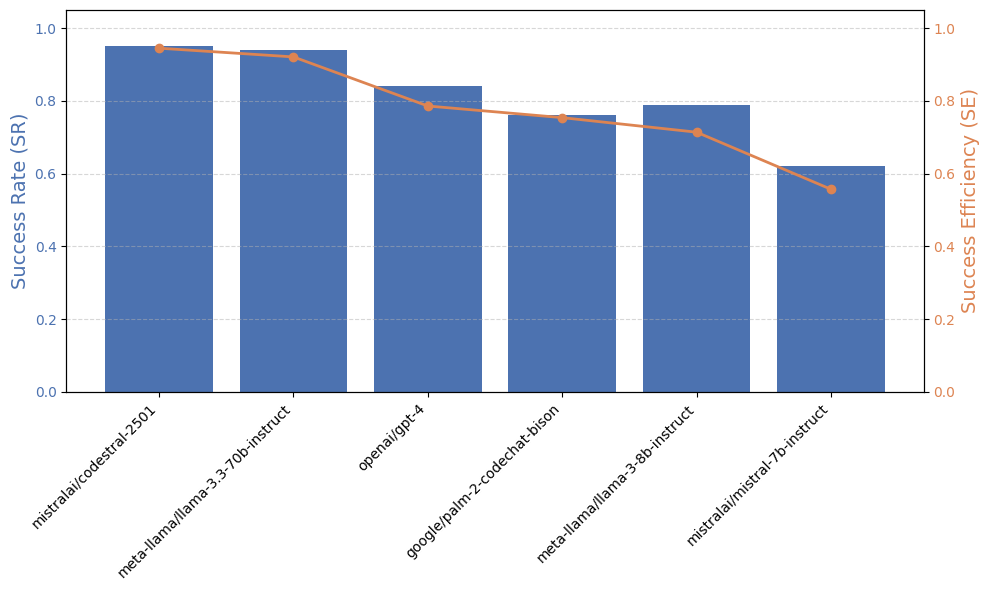

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(df.index, df["SR"], label="SR", color="#4C72B0")  # deep blue
ax1.set_ylabel("Success Rate (SR)", color="#4C72B0", fontsize = 14)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor="#4C72B0")
ax1.set_xticks(range(len(df.index)))
ax1.set_xticklabels(df.index, rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df.index, df["SE"], color="#DD8452", marker='o', linewidth=2, label="SE")  # strong orange
ax2.set_ylabel("Success Efficiency (SE)", color="#DD8452", fontsize = 14)
ax2.tick_params(axis='y', labelcolor="#DD8452")
ax2.set_ylim(0, 1.05)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

